In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Veri setini yükleme
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mkö-cm-5.hafta/diabetes.csv')

# İlk 5 satırı görüntüle
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Dataset Değişkenleri**

Pregnancies: Hamilelik sayısı

Glucose: Glikoz seviyeleri

BloodPressure: Kan basıncı (mm Hg)

SkinThickness: Deri kıvrım kalınlığı (mm)

Insulin: İnsülin seviyeleri (mu U/ml)

BMI: Vücut Kitle İndeksi

DiabetesPedigreeFunction: Diyabet aile öyküsü fonksiyonu

Age: Yaş

Outcome: Hedef değişken (1: Diyabet, 0: Diyabet değil)

In [65]:
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [66]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [67]:
df.shape

(768, 9)

In [68]:
#değeri 0 olan sütunlardaki değerleri gösteriyoruz.
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
(df[missing_cols] == 0).sum()



,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [69]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [70]:
#eksik değerin yüzdesini göstermek için yaptığımız bir kod
missing_data_summary = df.isnull().sum().sort_values(ascending=False).to_frame(name='MissingCount')
missing_data_summary['MissingPercentage'] = (missing_data_summary['MissingCount'] / len(df)) * 100
print(missing_data_summary)

                          MissingCount  MissingPercentage
Pregnancies                          0                0.0
Glucose                              0                0.0
BloodPressure                        0                0.0
SkinThickness                        0                0.0
Insulin                              0                0.0
BMI                                  0                0.0
DiabetesPedigreeFunction             0                0.0
Age                                  0                0.0
Outcome                              0                0.0


In [71]:
#değeri 0 ile biten sütunları medyan ile dolduruyoruz
for col in missing_cols:
    median = df[col].median()
    df[col] = df[col].replace(0, median)

In [72]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [73]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [74]:
#yaş sütununu kategorileştirip Bebek", "Çocuk", "Genç", "Orta Yaş", "Yaşlı olarak ayırıyoruz ki model daha iyi öğrenebilsin.
df['AgeCategory'] = pd.cut(df['Age'],
                           bins=[0, 12, 18, 35, 55, 100],
                           labels=["Bebek", "Çocuk", "Genç", "Orta Yaş", "Yaşlı"])

In [75]:
df['Pregnancy_Age_Ratio'] = df['Pregnancies'] / (df['Age']) #hamile yaş oranını buluyoruz ve yeni bir sütuna atıyoruz

In [76]:
df['HealthRiskScore'] = df['BMI'] * df['Glucose'] #Vücut Kitle İndeks ve glukoz seviyesini çarparak Sağlık Risk Skoru çıkartıyoruz

In [77]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'AgeCategory',
       'Pregnancy_Age_Ratio', 'HealthRiskScore'],
      dtype='object')

In [78]:
# Yeni özellikleri kontrol etme
display(df[['AgeCategory','Pregnancy_Age_Ratio','HealthRiskScore']].head())

,AgeCategory,Pregnancy_Age_Ratio,HealthRiskScore
0,Orta Yaş,0.120000,4972.8
1,Genç,0.032258,2261.0
2,Genç,0.250000,4263.9
3,Genç,0.047619,2500.9
4,Genç,0.000000,5904.7


In [79]:
missing_data_summary = df.isnull().sum().sort_values(ascending=False).to_frame(name='MissingCount')
missing_data_summary['MissingPercentage'] = (missing_data_summary['MissingCount'] / len(df)) * 100
print(missing_data_summary)

                          MissingCount  MissingPercentage
Pregnancies                          0                0.0
Glucose                              0                0.0
BloodPressure                        0                0.0
SkinThickness                        0                0.0
Insulin                              0                0.0
BMI                                  0                0.0
DiabetesPedigreeFunction             0                0.0
Age                                  0                0.0
Outcome                              0                0.0
AgeCategory                          0                0.0
Pregnancy_Age_Ratio                  0                0.0
HealthRiskScore                      0                0.0


In [80]:
from sklearn.preprocessing import StandardScaler

# Sayısal sütunları seçme
numerical_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Pregnancy_Age_Ratio', 'HealthRiskScore']

# StandardScaler ile standartlaştırma
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Sonuçları kontrol etme
print("Z-Score Standartlaştırılmış Veri:")
print(df.head())

Z-Score Standartlaştırılmış Veri:
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.831114 -0.608201  0.167240   
1    -0.844885 -1.205066      -0.528319       0.180566 -0.608201 -0.851551   
2     1.233880  2.016662      -0.693761      -0.469981 -0.608201 -1.331838   
3    -0.844885 -1.073567      -0.528319      -0.469981 -0.006185 -0.633239   
4    -1.141852  0.504422      -2.679076       0.831114  0.695378  1.549885   

   DiabetesPedigreeFunction       Age  Outcome AgeCategory  \
0                  0.468492  1.425995        1    Orta Yaş   
1                 -0.365061 -0.190672        0        Genç   
2                  0.604397 -0.105584        1        Genç   
3                 -0.920763 -1.041549        0        Genç   
4                  5.484909 -0.020496        1        Genç   

   Pregnancy_Age_Ratio  HealthRiskScore  
0             0.144246         0.664853  
1            -0.929227        -1.181332 

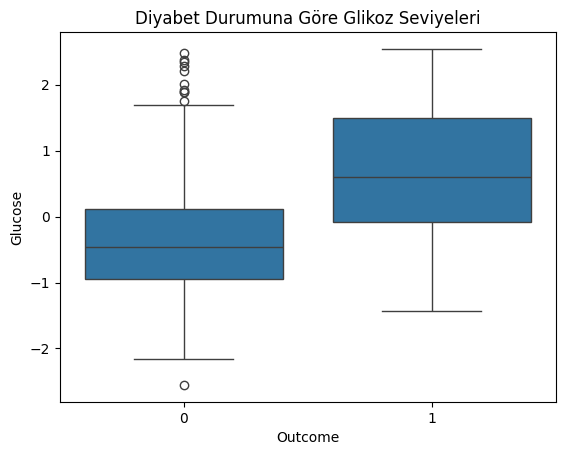

In [81]:

sns.boxplot(x=df['Outcome'], y=df['Glucose'])
plt.title("Diyabet Durumuna Göre Glikoz Seviyeleri")
plt.show()

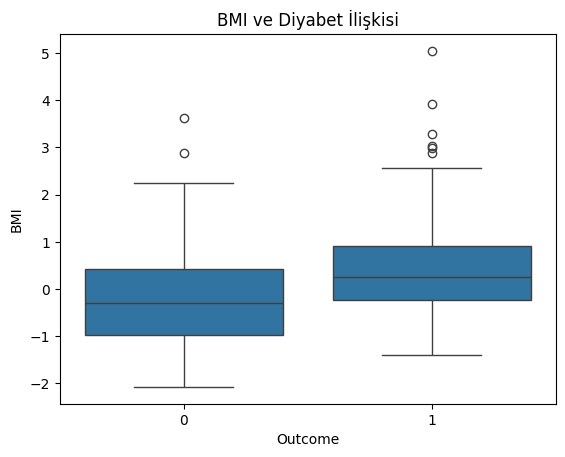

In [82]:
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI ve Diyabet İlişkisi")
plt.show()

In [83]:
# Yalnızca sayısal sütunları seçme
numeric_df = df.select_dtypes(include=['number'])                                       # HealthRiskScore             0.519906 en yüksek korelasyona sahip olan data. Ama orta seviye olduğu için çıkartmamıza gerek yok

# Korelasyon analizi
correlation_matrix = numeric_df.corr()
target_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print(target_corr)

Outcome                     1.000000
HealthRiskScore             0.519938
Glucose                     0.492782
BMI                         0.312249
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.189065
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Pregnancy_Age_Ratio         0.163744
Insulin                     0.148457
Name: Outcome, dtype: float64


In [84]:
# Kategorik sütunları belirleme
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Her kategorik sütunun unique değerlerini yazdırma
for col in categorical_columns:
    unique_values = df[col].unique()
    print(f"Sütun: {col}")
    print(f"Unique Değerler ({len(unique_values)}): {unique_values}")
    print("-" * 50)

Sütun: AgeCategory
Unique Değerler (3): ['Orta Yaş', 'Genç', 'Yaşlı']
Categories (5, object): ['Bebek' < 'Çocuk' < 'Genç' < 'Orta Yaş' < 'Yaşlı']
--------------------------------------------------


In [85]:
#age kategoriyi sayısallaştırmak için label encoder kullanıyoruz

from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Label Encoding uygulanacak değişkenler
label_encoding_columns = [
    'AgeCategory']

label_encoder = LabelEncoder()
for col in label_encoding_columns:
    if col in df.columns:
        df[col] = label_encoder.fit_transform(df[col])

In [86]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeCategory,Pregnancy_Age_Ratio,HealthRiskScore
0,0.639947,0.866045,-0.031990,0.831114,-0.608201,0.167240,0.468492,1.425995,1,1,0.144246,0.664853
1,-0.844885,-1.205066,-0.528319,0.180566,-0.608201,-0.851551,-0.365061,-0.190672,0,0,-0.929227,-1.181332
2,1.233880,2.016662,-0.693761,-0.469981,-0.608201,-1.331838,0.604397,-0.105584,1,0,1.734723,0.182236
3,-0.844885,-1.073567,-0.528319,-0.469981,-0.006185,-0.633239,-0.920763,-1.041549,0,0,-0.741294,-1.018009
4,-1.141852,0.504422,-2.679076,0.831114,0.695378,1.549885,5.484909,-0.020496,1,0,-1.323886,1.299288
5,0.342981,-0.185948,0.133453,-0.469981,-0.608201,-0.997092,-0.818079,-0.275760,0,0,0.715187,-0.698919
6,-0.250952,-1.435189,-1.851862,0.505840,-0.063068,-0.211168,-0.676133,-0.616111,1,0,0.087780,-1.074447
7,1.827813,-0.218823,-0.031990,-0.469981,-0.608201,0.414661,-1.020427,-0.360847,0,0,2.894885,0.043081
8,-0.547919,2.476909,-0.197433,1.915359,4.250593,-0.283939,-0.947944,1.681259,1,1,-0.862209,1.369955
9,1.233880,0.109925,1.953325,-0.469981,-0.608201,-0.065626,-0.724455,1.766346,1,1,0.488623,0.002574


In [89]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=0, stratify=Y)  #modeli test ve train olarak 2 ye ayırdık.

In [88]:
Y=df['Outcome']
X=df.drop('Outcome',axis=1)

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Modeli oluştur ve eğit
model = RandomForestClassifier(n_estimators=100, random_state=42)
#model = RandomForestClassifier(n_estimators=100, min_samples_split=10, min_samples_leaf=4, random_state=42)

model.fit(X_train, Y_train)



# Test seti ile tahmin yap
y_pred = model.predict(X_test)

# Model doğruluğunu ölç
accuracy = accuracy_score(Y_test, y_pred)
print(f"Random Forest Doğruluk: {accuracy:.4f}")

Random Forest Doğruluk: 0.7857


In [91]:
y_predict = model.predict(X_test)

from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=0,stratify=df['Outcome'])

from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,Y_train)
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(Y_test,y_predict)
print("Accuracy : ",round(accuracy,2)*100,'%')

Accuracy :  79.0 %


bu notebook'ta diabetes veri setine özellik mühendisliği yaptık. ilk başta eksik veriler medyan ile dolduruldu, verisetine yeni değişkenler ekledik ki model daha iyi öğrenebilsin.Ardından sayısal verileri normalize ettik(standart scaler ile) böylelikle her özelliğin katkısı eşitlenmiş oldu. Görselleştirme ve korelasyon analizi ile label ile ilgili önemli özellikler analiz edildi. Sonrasında random forest ve Logistic Regression ile başarı oranlarını değerlendirdik.